Step 1: Install Libraries & Load Data

In [1]:
!pip install ultralytics
!pip install roboflow
import os
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


def white_balance(img):
    """
    Standardizes lighting using the Gray World assumption.
    Required for accurate color extraction under different lights.
    """
    result = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    avg_a = np.average(result[:, :, 1])
    avg_b = np.average(result[:, :, 2])
    result[:, :, 1] = result[:, :, 1] - ((avg_a - 128) * (result[:, :, 0] / 255.0) * 1.1)
    result[:, :, 2] = result[:, :, 2] - ((avg_b - 128) * (result[:, :, 0] / 255.0) * 1.1)
    result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)
    return result


from roboflow import Roboflow
rf = Roboflow(api_key="C9gLQrmGWptAbZJRPfci")
project = rf.workspace("pramodya-priyasanka").project("urine-test-strips-main-2-foyeq")
version = project.version(1)
dataset = version.download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Urine-Test-Strips-(Main)-2-1 in yolov8:: 100%|██████████| 874/874 [00:03<00:00, 244.77it/s]


Dataset downloaded to: c:\Users\shehani\Desktop\Test\Urine-Test-Strips-(Main)-2-1


Step 2: Segmentation (Train YOLOv8)

In [3]:
model = YOLO('yolov8n.pt')
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    plots=True
)
metrics = model.val()
print(f"Map50-95: {metrics.box.map}")

Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Urine-Test-Strips-(Main)-2-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

Step 3: Feature Extraction Pipeline

In [4]:
def extract_color_features(image_path, model):
    """
    1. Detects pads using YOLO.
    2. Crops the pad image.
    3. Converts to HSV and calculates average color.
    """
    original_img = cv2.imread(image_path)
    balanced_img = white_balance(original_img)
    results = model(image_path)

    features = []
    for r in results:

        boxes = r.boxes
        for box in boxes:

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            cls = int(box.cls[0])
            label_name = model.names[cls]


            pad_img = balanced_img[y1:y2, x1:x2]
            pad_img = cv2.GaussianBlur(pad_img, (3, 3), 0)
            hsv_img = cv2.cvtColor(pad_img, cv2.COLOR_BGR2HSV)
            avg_hsv = np.mean(hsv_img, axis=(0, 1))

            features.append({
                'pad_type': label_name,
                'h_avg': avg_hsv[0],
                's_avg': avg_hsv[1],
                'v_avg': avg_hsv[2]
            })

    return pd.DataFrame(features)

Step 4: SVM Model (Support Vector Machine)



In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix


def generate_realistic_data(n_samples=500):
    data = []
    for _ in range(n_samples):
        if np.random.rand() > 0.5:
            h = int(np.random.normal(100, 15))
            label = "Normal"
        else:
            h = int(np.random.normal(60, 15))
            label = "High"
        h = np.clip(h, 0, 179)
        s = np.random.randint(50, 255)
        v = np.random.randint(50, 255)

        data.append([h, s, v, label])

    return pd.DataFrame(data, columns=['h', 's', 'v', 'label'])

df_train = generate_realistic_data()
X = df_train[['h', 's', 'v']]
y = df_train['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)


y_pred = svm_classifier.predict(X_test)

print("--- SVM Classification Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- SVM Classification Accuracy ---
Accuracy: 89.00%

Confusion Matrix:
[[49  4]
 [ 7 40]]


 K-Nearest Neighbors (KNN) / Random Forest (RF)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_y_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_y_pred)

# 2. Random Forest (RF)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_y_pred)

print("--- Model Accuracy Comparison ---")
print(f"KNN Accuracy:           {knn_accuracy * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")


--- Model Accuracy Comparison ---
KNN Accuracy:           84.00%
Random Forest Accuracy: 90.00%


Step 4.5: Upload & Visually Verify

Please upload a urine strip image to test:


Saving IMG_3623_png.rf.e3c2ef47a93b84ef0437d07ef6145f6f.jpg to IMG_3623_png.rf.e3c2ef47a93b84ef0437d07ef6145f6f.jpg

image 1/1 /content/IMG_3623_png.rf.e3c2ef47a93b84ef0437d07ef6145f6f.jpg: 640x480 1 Bilirubin, 1 Glucose, 1 Ketone, 1 SpGravity, 1 strip, 147.4ms
Speed: 4.7ms preprocess, 147.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)

--- Analysis Results ---
Detected strip: High (HSV: [ 41  41 177])
Detected SpGravity: High (HSV: [ 24  23 172])
Detected Glucose: High (HSV: [ 26  29 149])
Detected Bilirubin: High (HSV: [ 26  26 158])
Detected Ketone: High (HSV: [ 26  24 168])


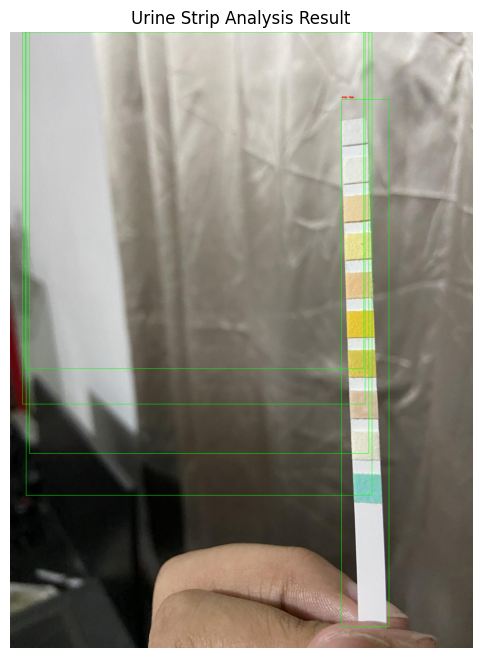

In [9]:
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import numpy as np


print("Please upload a urine strip image to test:")
uploaded = files.upload()
filename = next(iter(uploaded))
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = model(filename)
output_img = img_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX

print("\n--- Analysis Results ---")

found_pads = False
for r in results:
    boxes = r.boxes
    for box in boxes:
        found_pads = True
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls = int(box.cls[0])
        pad_name = model.names[cls]
        pad_crop = img[y1:y2, x1:x2]
        pad_crop = cv2.GaussianBlur(pad_crop, (3, 3), 0)
        hsv_crop = cv2.cvtColor(pad_crop, cv2.COLOR_BGR2HSV)
        avg_hsv = np.mean(hsv_crop, axis=(0, 1))
        input_df = pd.DataFrame([avg_hsv], columns=['h', 's', 'v'])
        diagnosis = svm_classifier.predict(input_df)[0]
        print(f"Detected {pad_name}: {diagnosis} (HSV: {avg_hsv.astype(int)})")
        cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label_text = f"{pad_name}: {diagnosis}"
        cv2.putText(output_img, label_text, (x1, y1 - 10), font, 0.5, (255, 0, 0), 2)

if not found_pads:
    print("No urine strip pads were detected. Try an image with better lighting.")
plt.figure(figsize=(12, 8))
plt.imshow(output_img)
plt.axis('off')
plt.title("Urine Strip Analysis Result")
plt.show()

Step 5: The Final Application Logic

In [ ]:
def analyze_urine_strip(image_path):
    """
    Full Pipeline:
    1. Preprocesses image (White Balance) - implicitly called inside extract_color_features
    2. Segments pads (YOLO)
    3. Extracts Color (HSV)
    4. Classifies Health Status (SVM)
    """
    pad_data = extract_color_features(image_path, model)
    if pad_data.empty:
        return {"error": "No strip detected. Please try a clearer image."}

    results = {}
    for index, row in pad_data.iterrows():
        pad_name = row['pad_type']

        features = [[row['h_avg'], row['s_avg'], row['v_avg']]]
        input_df = pd.DataFrame(features, columns=['h', 's', 'v'])
        diagnosis = svm_classifier.predict(input_df)[0]
        results[pad_name] = {
            "hsv_values": features[0],
            "diagnosis": diagnosis
        }

    return results